In [103]:
#Importing the required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [104]:
#Loading and merging the matches and deliveries dataset
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")
ipl = deliveries.merge(matches,left_on="ID",right_on="match_number",how="left")

#Displaying shape, column names and datatypes
print("Shape:", ipl.shape)
print("\nColumns:")
print(ipl.columns.tolist())
print("\nData Types:")
print(ipl.dtypes)
print("\nThis dataset covers from year 2008 to year 2025.")

Shape: (295732, 30)

Columns:
['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler', 'NonStriker', 'ExtraType', 'BatsmanRun', 'ExtrasRun', 'TotalRun', 'IsWicketDelivery', 'PlayerOut', 'Kind', 'FieldersInvolved', 'BattingTeam', 'match_number', 'team1', 'team2', 'match_date', 'toss_winner', 'toss_decision', 'result', 'eliminator', 'winner', 'player_of_match', 'venue', 'city', 'team1_players', 'team2_players']

Data Types:
ID                   int64
Innings              int64
Overs                int64
BallNumber           int64
Batter              object
Bowler              object
NonStriker          object
ExtraType           object
BatsmanRun           int64
ExtrasRun            int64
TotalRun             int64
IsWicketDelivery     int64
PlayerOut           object
Kind                object
FieldersInvolved    object
BattingTeam         object
match_number         int64
team1               object
team2               object
match_date          object
toss_winner         object
tos

In [105]:
#Finding out missing values
print("\nMissing Values:")
print(matches.isnull().sum()) 
#In the venue missing values, we used imputation instead of dropping values because venue is not a significant match variable. 
matches["venue"] = matches["venue"].fillna(matches["venue"].mode()[0])
#In the case of player of the match, the missing values were filled with a placeholder because dropping would lead to loss of important data.
matches["player_of_the_match"] = matches["player_of_match"].fillna("No Award")


Missing Values:
match_number          0
team1                 0
team2                 0
match_date            0
toss_winner           0
toss_decision         0
result                0
eliminator         1227
winner               25
player_of_match       0
venue                 0
city                 51
team1_players         0
team2_players         0
dtype: int64


In [106]:
deliveries["total_runs"] = deliveries["BatsmanRun"] + deliveries["ExtrasRun"]

deliveries["is_boundary"] = np.where(
    deliveries["BatsmanRun"] >= 4,
    "boundary",
    "non-boundary"
)
#1-6 is powerplay, 7-16 is middle overs, 17-20 is death overs
deliveries["over_phase"] = np.where(
    deliveries["Overs"] >=7,
    np.where(deliveries["Overs"] >=17,
             "Death Overs",
             "Middle Overs"
            ),
    "Powerplay"
)
#Converting to datetime
matches["match_date"] = pd.to_datetime(matches["match_date"])
matches["year"] = matches["match_date"].dt.year
matches["month"] = matches["match_date"].dt.month

In [107]:
top_batsmen = (
    deliveries.groupby("Batter")["BatsmanRun"]
        .sum()
        .sort_values(ascending=False)
)
print("Top 5 Batsmen")
print(top_batsmen.head(5)) #Since we only need the top 5

legal_deliveries = deliveries[(deliveries["ExtraType"] != "wides" ) & (deliveries["ExtraType"] != "noballs")]
balls_bowled = (legal_deliveries.groupby("Bowler").size())
runs_conceded = (deliveries.groupby("Bowler")["TotalRun"].sum())

bowler_stats = pd.DataFrame({"balls": balls_bowled,"runs": runs_conceded})
bowler_stats = bowler_stats[bowler_stats["balls"] >= 500]
bowler_stats["economy_rate"] = (bowler_stats["runs"] / bowler_stats["balls"]*6)
bowler_stats = bowler_stats.sort_values("economy_rate")
print("Bowlers with more than 500 balls bowled")
print(bowler_stats)
#Team with highest win% for each season
matches["season"] = matches["match_date"].dt.year
season_results = []
for season in matches["season"].unique():
    temp = matches[matches["season"] == season]
    total_played = pd.concat([temp["team1"],temp["team2"]]).value_counts()
    wins = temp["winner"].value_counts()
    win_pct = (wins / total_played * 100).sort_values(ascending=False)
    season_results.append([season,win_pct.index[0],round(win_pct.iloc[0], 2)])
season_win_pct = pd.DataFrame(season_results,columns=["Season","Best Team","Win Percentage"])
print(season_win_pct)

Top 5 Batsmen
Batter
V Kohli      9346
RG Sharma    7331
S Dhawan     6769
DA Warner    6567
KL Rahul     5828
Name: BatsmanRun, dtype: int64
Bowlers with more than 500 balls bowled
                   balls  runs  economy_rate
Bowler                                      
A Kumble             965  1089      6.770984
DL Vettori           777   894      6.903475
SP Narine           4660  5379      6.925751
M Muralitharan      1528  1765      6.930628
J Botha              694   818      7.072046
...                  ...   ...           ...
Kartik Tyagi         728  1224     10.087912
MP Stoinis           935  1575     10.106952
TU Deshpande        1104  1899     10.320652
Vijaykumar Vyshak    519   910     10.520231
Mukesh Kumar         824  1475     10.740291

[152 rows x 3 columns]
    Season                    Best Team  Win Percentage
0     2011          Chennai Super Kings           68.75
1     2020               Mumbai Indians           68.75
2     2023               Gujarat Titans  

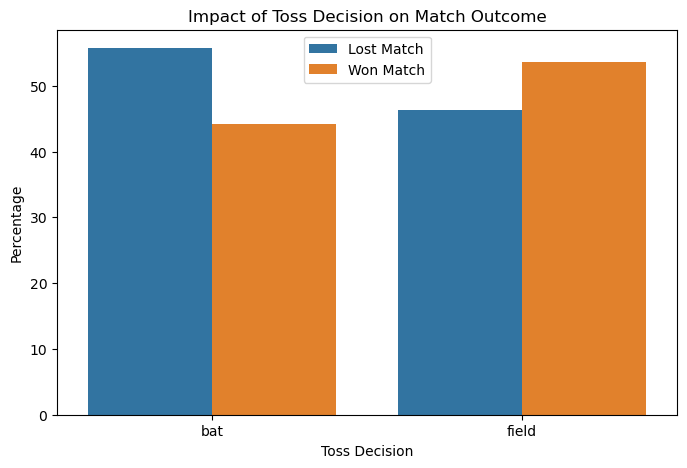

In [108]:
#Determining toss impact on match outcome
matches["toss_success"] = np.where(matches["toss_winner"] == matches["winner"],"Won Match","Lost Match")
toss_analysis = (matches.groupby(["toss_decision", "toss_success"]).size().reset_index(name="count"))
total = toss_analysis.groupby("toss_decision")["count"].transform("sum")
toss_analysis["percentage"] = (toss_analysis["count"] / total * 100)
plt.figure(figsize=(8,5))
sns.barplot(data=toss_analysis,x="toss_decision",y="percentage",hue="toss_success")
plt.title("Impact of Toss Decision on Match Outcome")
plt.xlabel("Toss Decision")
plt.ylabel("Percentage")
plt.legend()
plt.show()

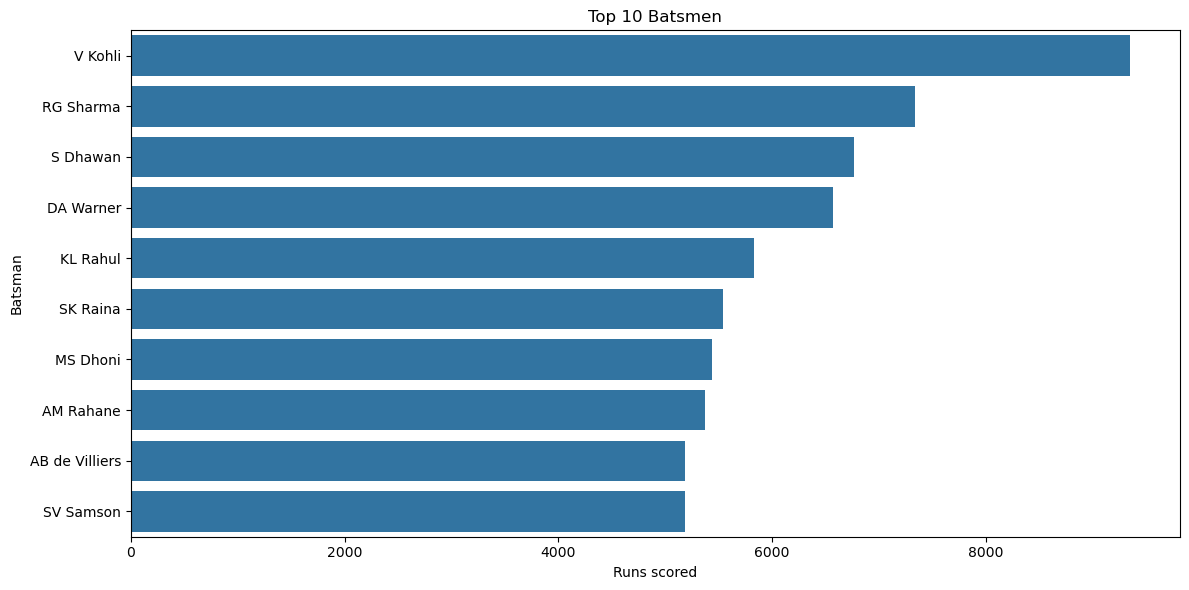

In [109]:
#Top 10 Run-scorers
plt.figure(figsize=(12,6))
sns.barplot(x=top_batsmen.head(10).values,y=top_batsmen.head(10).index)
plt.title("Top 10 Batsmen")
plt.xlabel("Runs scored")
plt.ylabel("Batsman")
plt.tight_layout()
plt.show()

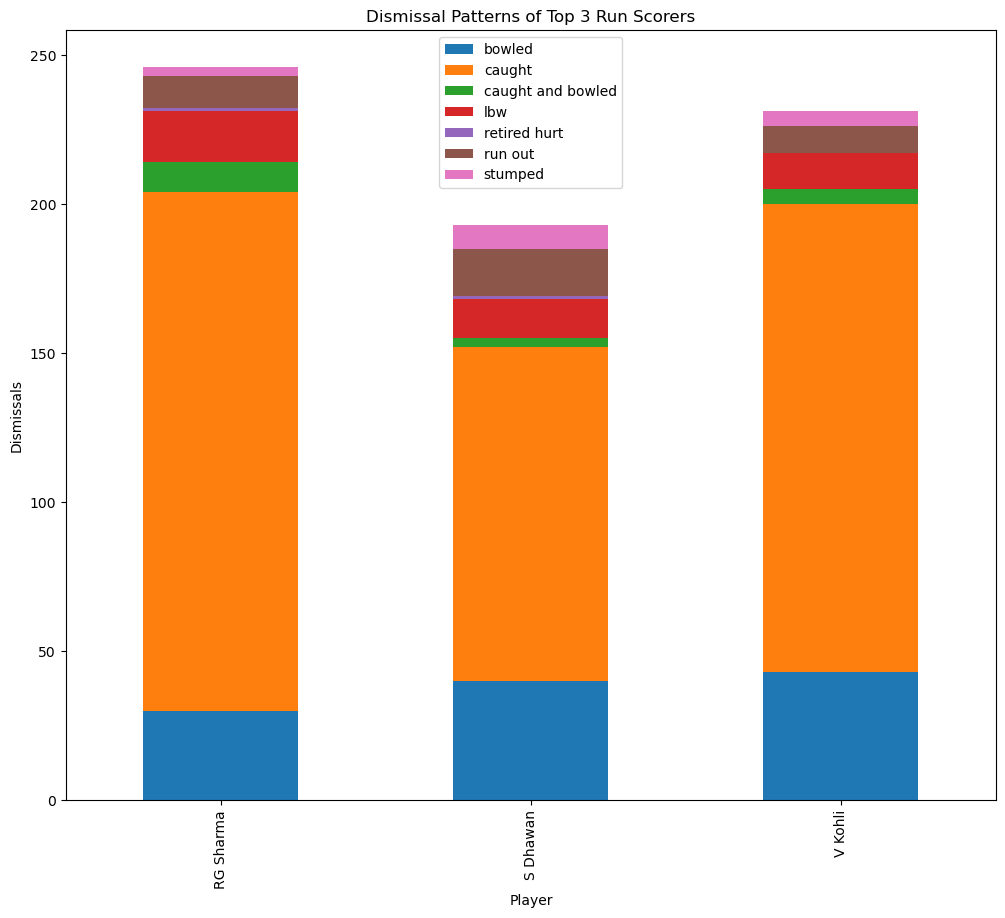

In [110]:
#Dismissal patterns of top 3 run scorers
top3 = top_batsmen.head(3).index
dismissals = deliveries[(deliveries["PlayerOut"].isin(top3)) &(deliveries["IsWicketDelivery"] == 1)]
dismissal_pattern = pd.crosstab(dismissals["PlayerOut"],dismissals["Kind"])
dismissal_pattern.plot(kind="bar",stacked=True,figsize=(12,10))
plt.title("Dismissal Patterns of Top 3 Run Scorers")
plt.xlabel("Player")
plt.ylabel("Dismissals")
plt.legend()
plt.show()

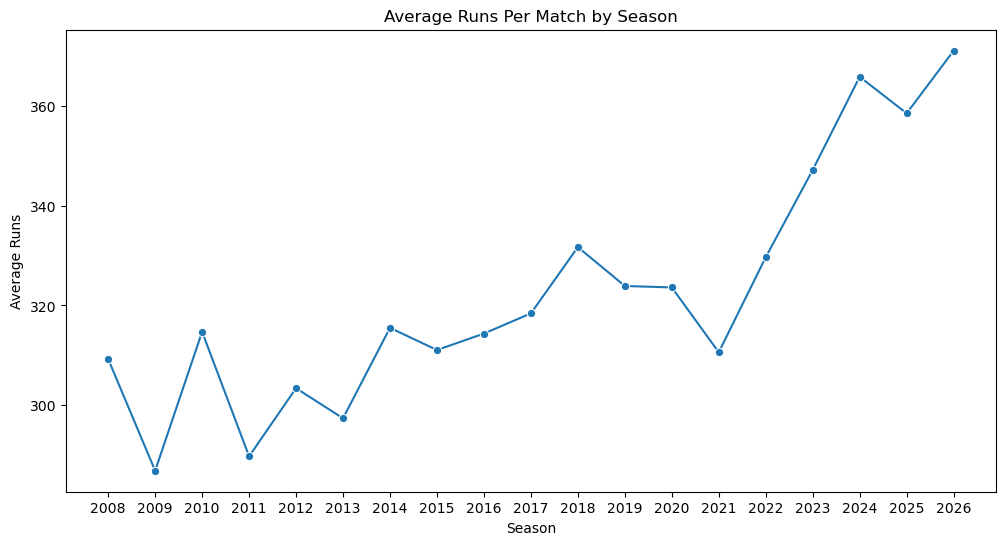

In [111]:
#Finding average runs per season for each season
ipl = deliveries.merge(matches,left_on="ID",right_on="match_number",how="left")
season_runs = (ipl.groupby("season")["total_runs"].sum())
season_matches = (matches.groupby("season").size())
avg_runs = (season_runs / season_matches)
avg_runs = avg_runs.reset_index()
avg_runs.columns = ["season","avg_runs_per_match"]
plt.figure(figsize=(12,6))
sns.lineplot(data=avg_runs,x="season",y="avg_runs_per_match",marker="o")
plt.xticks(avg_runs["season"])
plt.title("Average Runs Per Match by Season")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.show()

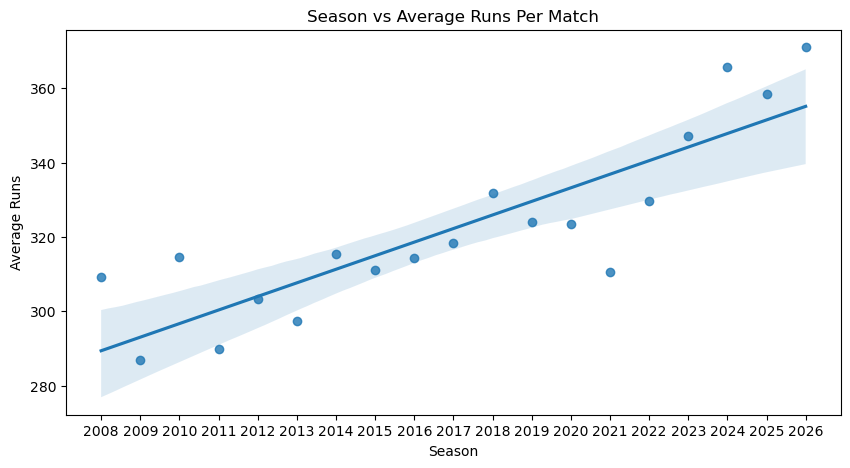

In [112]:
#Finding if ipl is becoming high scoring over time using regression line
plt.figure(figsize=(10,5))
sns.regplot(data=avg_runs,x="season",y="avg_runs_per_match")
plt.xticks(avg_runs["season"])
plt.title("Season vs Average Runs Per Match")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.show()

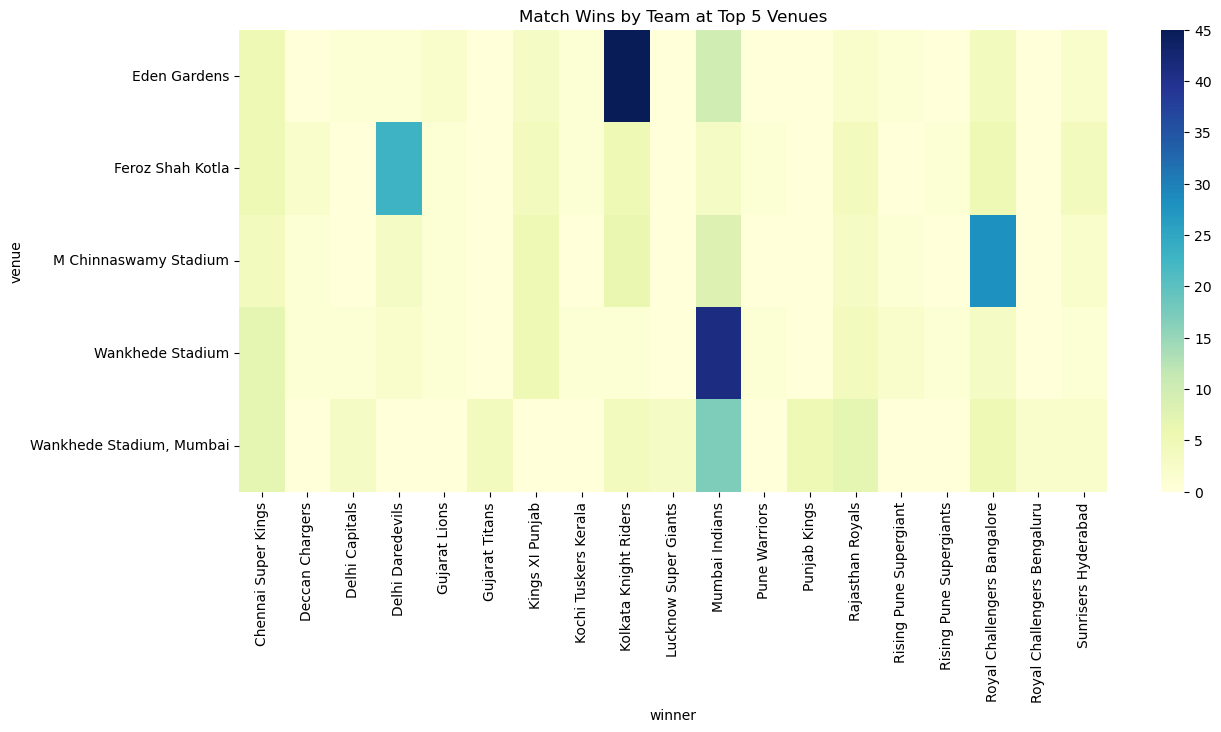

In [113]:
#Heatmap of win counts by team on top 5 venues
top5_venues = (matches["venue"].value_counts().head(5).index)
venue_df = matches[matches["venue"].isin(top5_venues)]
heatmap_data = pd.crosstab(venue_df["venue"],venue_df["winner"])
plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data,cmap="YlGnBu")
plt.title("Match Wins by Team at Top 5 Venues")
plt.show()

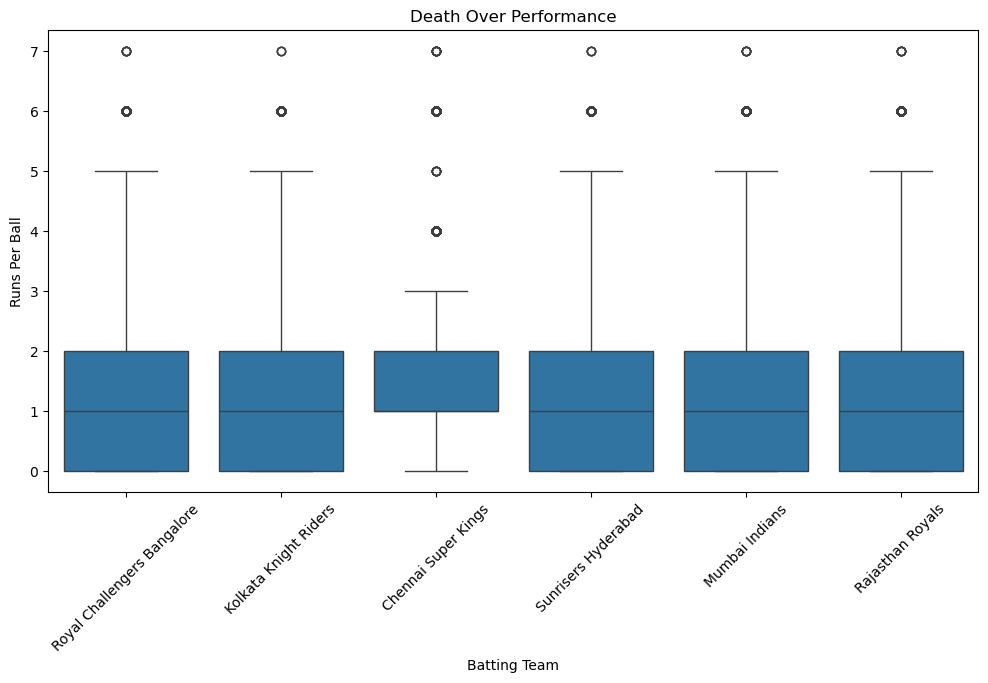


Death Over Summary
                                  std
BattingTeam                          
Mumbai Indians               1.872994
Royal Challengers Bangalore  1.848003
Chennai Super Kings          1.808097
Kolkata Knight Riders        1.790597
Sunrisers Hyderabad          1.764786
Rajasthan Royals             1.752599


In [114]:
#Boxplot for runs scored in death overs for top 6 teams
death_overs = ipl[ipl["Overs"].between(16, 20)]
top6_teams = (death_overs.groupby("BattingTeam")["total_runs"].sum().sort_values(ascending=False).head(6).index)
death_overs = death_overs[death_overs["BattingTeam"].isin(top6_teams)]
plt.figure(figsize=(12,6))
sns.boxplot(data=death_overs,x="BattingTeam",y="total_runs")
plt.title("Death Over Performance")
plt.xlabel("Batting Team")
plt.ylabel("Runs Per Ball")
plt.xticks(rotation=45)
plt.show()
#Death overs summary
death_summary = (death_overs.groupby("BattingTeam")["total_runs"].agg(["std"]).sort_values(by=["std"],ascending=False))
print("\nDeath Over Summary")
print(death_summary)